# DS 4320 Project 2: Loan Default Risk — Data Creation & Pipeline
This notebook handles the full workflow for the Loan Default Risk project.
It loads the raw CSV dataset from Kaggle, applies transformations to create
a secondary dataset D1, inserts it into MongoDB Atlas, then queries the data
back out, prepares features, trains a model, and visualizes results.

## 1. Install Dependencies

In [1]:
# Install required libraries
!pip install pymongo pandas scikit-learn matplotlib seaborn python-dotenv


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Imports

In [2]:
import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from pymongo import MongoClient

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Configure logging so all steps are recorded
logging.basicConfig(
    filename='data_creation.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logging.info('Notebook started')

/Users/leahkim/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 3. Load Raw Data

The raw dataset was downloaded from Kaggle: [Loan Default Dataset](https://www.kaggle.com/datasets/nikhil1e9/loan-default)

It is stored locally in the `data/` folder and read directly from there.

In [3]:
try:
    # Read CSV directly from the data folder
    df_raw = pd.read_csv('../data/Loan_default.csv')
    logging.info(f'CSV loaded successfully with {len(df_raw)} rows and {len(df_raw.columns)} columns')
    print(f'Rows: {len(df_raw)}')
    print(f'Columns: {len(df_raw.columns)}')
    print(f'\nColumn names: {list(df_raw.columns)}')
except Exception as e:
    logging.error(f'Failed to load CSV: {e}')
    raise

Rows: 255347
Columns: 18

Column names: ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [4]:
# Preview the first few rows
df_raw.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
# Check data types and null counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [6]:
# Check for missing values per column
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found')
logging.info(f'Missing value check complete: {missing.sum()} total missing values')

Missing values per column:
No missing values found


In [7]:
# Check distribution of target variable
print('Default value counts:')
print(df_raw['Default'].value_counts())
print(f'\nDefault rate: {df_raw["Default"].mean()*100:.2f}%')

Default value counts:
Default
0    225694
1     29653
Name: count, dtype: int64

Default rate: 11.61%


## 4. Create Secondary Dataset D1 — Transformations

We apply a series of transformations to the raw data to create D1, a richer and more
analytically useful secondary dataset. Each transformation adds new derived fields
that are grounded in the actual data rather than introduced from an external source.

Transformations applied:
- `credit_tier` — categorizes CreditScore into standard lending tiers
- `income_bracket` — buckets Income into low, medium, and high
- `debt_burden` — classifies DTIRatio into low, moderate, and high
- `loan_size` — categorizes LoanAmount into small, medium, and large
- `default_rate_by_employment` — average default rate for each employment type
- `default_rate_by_purpose` — average default rate for each loan purpose
- `default_rate_by_education` — average default rate for each education level
- `risk_flag` — binary flag combining multiple high risk indicators

In [8]:
try:
    # Work on a copy so the raw data is preserved
    df = df_raw.copy()

    # ── Transformation 1: Credit Tier ─────────────────────────────────────────
    # Buckets CreditScore into standard lending tiers used by credit bureaus
    def assign_credit_tier(score):
        if score >= 740:
            return 'Excellent'
        elif score >= 670:
            return 'Good'
        elif score >= 580:
            return 'Fair'
        else:
            return 'Poor'

    df['credit_tier'] = df['CreditScore'].apply(assign_credit_tier)
    print('credit_tier value counts:')
    print(df['credit_tier'].value_counts())

except Exception as e:
    logging.error(f'Transformation 1 failed: {e}')
    raise

credit_tier value counts:
credit_tier
Poor         130223
Excellent     51204
Fair          41847
Good          32073
Name: count, dtype: int64


In [9]:
try:
    # ── Transformation 2: Income Bracket ──────────────────────────────────────
    # Buckets Income into three tiers based on percentile cutoffs
    low_cutoff    = df['Income'].quantile(0.33)
    high_cutoff   = df['Income'].quantile(0.66)

    def assign_income_bracket(income):
        if income <= low_cutoff:
            return 'Low'
        elif income <= high_cutoff:
            return 'Medium'
        else:
            return 'High'

    df['income_bracket'] = df['Income'].apply(assign_income_bracket)
    print('income_bracket value counts:')
    print(df['income_bracket'].value_counts())

except Exception as e:
    logging.error(f'Transformation 2 failed: {e}')
    raise

income_bracket value counts:
income_bracket
High      86816
Low       84266
Medium    84265
Name: count, dtype: int64


In [10]:
try:
    # ── Transformation 3: Debt Burden ─────────────────────────────────────────
    # Classifies DTIRatio (debt-to-income) into risk levels
    # DTI < 0.35 is generally considered healthy by lenders
    def assign_debt_burden(dti):
        if dti < 0.35:
            return 'Low'
        elif dti < 0.50:
            return 'Moderate'
        else:
            return 'High'

    df['debt_burden'] = df['DTIRatio'].apply(assign_debt_burden)
    print('debt_burden value counts:')
    print(df['debt_burden'].value_counts())

except Exception as e:
    logging.error(f'Transformation 3 failed: {e}')
    raise

debt_burden value counts:
debt_burden
High        129297
Low          78089
Moderate     47961
Name: count, dtype: int64


In [11]:
try:
    # ── Transformation 4: Loan Size ───────────────────────────────────────────
    # Categorizes LoanAmount into small, medium, and large
    small_cutoff  = df['LoanAmount'].quantile(0.33)
    large_cutoff  = df['LoanAmount'].quantile(0.66)

    def assign_loan_size(amount):
        if amount <= small_cutoff:
            return 'Small'
        elif amount <= large_cutoff:
            return 'Medium'
        else:
            return 'Large'

    df['loan_size'] = df['LoanAmount'].apply(assign_loan_size)
    print('loan_size value counts:')
    print(df['loan_size'].value_counts())

except Exception as e:
    logging.error(f'Transformation 4 failed: {e}')
    raise

loan_size value counts:
loan_size
Large     86818
Small     84265
Medium    84264
Name: count, dtype: int64


In [12]:
try:
    # ── Transformation 5: Group Default Rates ─────────────────────────────────
    # Computes average default rate for each group and attaches it back
    # to each borrower as a new feature. This captures group-level risk
    # patterns that the individual features alone do not express.

    # Average default rate by employment type
    emp_default_rate = df.groupby('EmploymentType')['Default'].mean().rename('default_rate_by_employment')
    df = df.join(emp_default_rate, on='EmploymentType')

    # Average default rate by loan purpose
    purpose_default_rate = df.groupby('LoanPurpose')['Default'].mean().rename('default_rate_by_purpose')
    df = df.join(purpose_default_rate, on='LoanPurpose')

    # Average default rate by education level
    edu_default_rate = df.groupby('Education')['Default'].mean().rename('default_rate_by_education')
    df = df.join(edu_default_rate, on='Education')

    print('Group default rates added successfully')
    print(df[['EmploymentType', 'default_rate_by_employment',
              'LoanPurpose', 'default_rate_by_purpose',
              'Education', 'default_rate_by_education']].drop_duplicates().head(10))

except Exception as e:
    logging.error(f'Transformation 5 failed: {e}')
    raise

Group default rates added successfully
  EmploymentType  default_rate_by_employment LoanPurpose  \
0      Full-time                    0.094634       Other   
1      Full-time                    0.094634       Other   
2     Unemployed                    0.135529        Auto   
3      Full-time                    0.094634    Business   
4     Unemployed                    0.135529        Auto   
5     Unemployed                    0.135529    Business   
6     Unemployed                    0.135529        Home   
7      Full-time                    0.094634        Home   
8  Self-employed                    0.114620   Education   
9  Self-employed                    0.114620       Other   

   default_rate_by_purpose    Education  default_rate_by_education  
0                 0.117885   Bachelor's                   0.121011  
1                 0.117885     Master's                   0.108717  
2                 0.118814     Master's                   0.108717  
3                 0.1232

In [13]:
try:
    # ── Transformation 6: Risk Flag ───────────────────────────────────────────
    # Creates a binary flag that marks borrowers who meet multiple high risk
    # criteria simultaneously. A borrower is flagged if they have:
    # poor/fair credit, high debt burden, and low income
    df['risk_flag'] = (
        (df['credit_tier'].isin(['Poor', 'Fair'])) &
        (df['debt_burden'] == 'High') &
        (df['income_bracket'] == 'Low')
    ).astype(int)

    print('risk_flag value counts:')
    print(df['risk_flag'].value_counts())
    print(f'\nDefault rate for flagged borrowers:    {df[df["risk_flag"]==1]["Default"].mean()*100:.2f}%')
    print(f'Default rate for non-flagged borrowers: {df[df["risk_flag"]==0]["Default"].mean()*100:.2f}%')

    logging.info('All transformations applied successfully')
    print('\nAll transformations complete!')
    print(f'D1 shape: {df.shape}')
    print(f'New columns added: {[c for c in df.columns if c not in df_raw.columns]}')

except Exception as e:
    logging.error(f'Transformation 6 failed: {e}')
    raise

risk_flag value counts:
risk_flag
0    226658
1     28689
Name: count, dtype: int64

Default rate for flagged borrowers:    17.06%
Default rate for non-flagged borrowers: 10.92%

All transformations complete!
D1 shape: (255347, 26)
New columns added: ['credit_tier', 'income_bracket', 'debt_burden', 'loan_size', 'default_rate_by_employment', 'default_rate_by_purpose', 'default_rate_by_education', 'risk_flag']


In [14]:
# Preview D1
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,HasCoSigner,Default,credit_tier,income_bracket,debt_burden,loan_size,default_rate_by_employment,default_rate_by_purpose,default_rate_by_education,risk_flag
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,...,Yes,0,Poor,Medium,Moderate,Small,0.094634,0.117885,0.121011,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,...,Yes,0,Poor,Low,High,Medium,0.094634,0.117885,0.108717,1
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,...,No,1,Poor,Medium,Low,Medium,0.135529,0.118814,0.108717,0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,...,No,0,Excellent,Low,Low,Small,0.094634,0.123260,0.128789,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,...,No,0,Fair,Low,High,Small,0.135529,0.118814,0.121011,1


## 5. Data Validation
Before inserting into MongoDB, we validate that D1 meets basic quality requirements.

In [15]:
try:
    # Validate no duplicate LoanIDs
    assert df['LoanID'].nunique() == len(df), 'Duplicate LoanIDs found'

    # Validate Default column only contains 0 and 1
    assert set(df['Default'].unique()).issubset({0, 1}), 'Default column contains unexpected values'

    # Validate all new columns were created
    new_cols = [
        'credit_tier', 'income_bracket', 'debt_burden', 'loan_size',
        'default_rate_by_employment', 'default_rate_by_purpose',
        'default_rate_by_education', 'risk_flag'
    ]
    missing_new = [c for c in new_cols if c not in df.columns]
    assert len(missing_new) == 0, f'Missing transformed columns: {missing_new}'

    # Validate no nulls were introduced by transformations
    assert df.isnull().sum().sum() == 0, 'Nulls found after transformations'

    print('All validation checks passed!')
    logging.info('D1 validation passed')

except AssertionError as e:
    logging.error(f'Validation failed: {e}')
    raise

All validation checks passed!


## 6. Connect to MongoDB Atlas

In [ ]:
try:
    # Load environment variables from .env file
    load_dotenv()

    # Connect using environment variable — never hardcode credentials
    client = MongoClient(
        os.getenv('MONGO_URI'),
        tls=True,
        tlsAllowInvalidCertificates=True
    )

    # Select database and collection
    db = client['sxk2eh']  # replace with your actual UVA computing ID
    collection = db['loan_default']

    print('Connected to MongoDB Atlas')
    print('Available databases:', client.list_database_names())
    logging.info('MongoDB connection established successfully')

except Exception as e:
    logging.error(f'MongoDB connection failed: {e}')
    raise

Connected to MongoDB Atlas
Available databases: ['sample_mflix', 'sxk2eh', 'your_uva_id', 'admin', 'local']


## 7. Insert D1 into MongoDB
We insert the transformed dataset D1 into MongoDB, not the raw CSV.
We drop the collection before inserting to avoid duplicates on re-runs
and insert in batches of 1000 to avoid connection timeouts.

In [17]:
try:
    # Drop collection if it already exists to avoid duplicate inserts on re-runs
    collection.drop()
    logging.info('Existing collection dropped before fresh insert')

    # Convert D1 DataFrame rows to list of dicts for MongoDB insertion
    records = df.to_dict(orient='records')

    # Insert in batches of 1000 to avoid connection timeout
    batch_size = 1000
    total_inserted = 0

    for i in range(0, len(records), batch_size):
        batch = records[i : i + batch_size]
        result = collection.insert_many(batch)
        total_inserted += len(result.inserted_ids)
        print(f'Inserted {total_inserted} / {len(records)} documents...', end='\r')

    print(f'\nSuccessfully inserted {total_inserted} documents')
    logging.info(f'Inserted {total_inserted} D1 documents into loan_default collection')

except Exception as e:
    logging.error(f'Insert failed: {e}')
    raise

Inserted 255347 / 255347 documents...
Successfully inserted 255347 documents


## 8. Verify Insertion

In [18]:
# Confirm document count matches D1 row count
count = collection.count_documents({})
print(f'Documents in MongoDB: {count}')
print(f'Rows in D1:           {len(df)}')
print(f'Match: {count == len(df)}')
logging.info(f'Verification complete: {count} documents in collection')

Documents in MongoDB: 255347
Rows in D1:           255347
Match: True


In [19]:
# Preview a sample document from MongoDB to confirm new fields are present
print('Sample D1 document from MongoDB:')
print(collection.find_one({}))

Sample D1 document from MongoDB:
{'_id': ObjectId('69e6a5c95d5f027ff51f1f15'), 'LoanID': 'I38PQUQS96', 'Age': 56, 'Income': 85994, 'LoanAmount': 50587, 'CreditScore': 520, 'MonthsEmployed': 80, 'NumCreditLines': 4, 'InterestRate': 15.23, 'LoanTerm': 36, 'DTIRatio': 0.44, 'Education': "Bachelor's", 'EmploymentType': 'Full-time', 'MaritalStatus': 'Divorced', 'HasMortgage': 'Yes', 'HasDependents': 'Yes', 'LoanPurpose': 'Other', 'HasCoSigner': 'Yes', 'Default': 0, 'credit_tier': 'Poor', 'income_bracket': 'Medium', 'debt_burden': 'Moderate', 'loan_size': 'Small', 'default_rate_by_employment': 0.094633655900465, 'default_rate_by_purpose': 0.11788506108339553, 'default_rate_by_education': 0.1210110928129758, 'risk_flag': 0}


## 9. Query MongoDB into DataFrame

Now that D1 is stored in MongoDB, we query it back out into a pandas DataFrame
for the analysis pipeline. This keeps data storage and analysis cleanly separated.

In [20]:
try:
    # Query all documents from MongoDB, excluding the _id field
    cursor = collection.find({}, {'_id': 0})
    df_model = pd.DataFrame(list(cursor))

    print(f'Queried {len(df_model)} documents from MongoDB into DataFrame')
    print(f'Columns: {list(df_model.columns)}')
    logging.info(f'Successfully queried {len(df_model)} documents from MongoDB')

except Exception as e:
    logging.error(f'Failed to query data from MongoDB: {e}')
    raise

Queried 255347 documents from MongoDB into DataFrame
Columns: ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default', 'credit_tier', 'income_bracket', 'debt_burden', 'loan_size', 'default_rate_by_employment', 'default_rate_by_purpose', 'default_rate_by_education', 'risk_flag']


## 10. Data Preparation for Modeling

We encode all categorical columns as integers since machine learning models
require numeric input. We also drop `LoanID` since it is just an identifier
with no predictive value.

In [21]:
try:
    # Drop LoanID — unique identifier with no predictive value
    df_model = df_model.drop(columns=['LoanID'])

    # Encode all remaining categorical columns
    categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
    print(f'Encoding categorical columns: {categorical_cols}')

    le = LabelEncoder()
    for col in categorical_cols:
        df_model[col] = le.fit_transform(df_model[col])

    print('Encoding complete')
    logging.info('Data preparation complete — all categorical columns encoded')

except Exception as e:
    logging.error(f'Data preparation failed: {e}')
    raise

Encoding categorical columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'credit_tier', 'income_bracket', 'debt_burden', 'loan_size']
Encoding complete


In [22]:
# Split into features (X) and target (y)
X = df_model.drop(columns=['Default'])
y = df_model['Default']

# 80/20 train/test split — stratify ensures both splits have the same default rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')
logging.info(f'Train/test split: {len(X_train)} train, {len(X_test)} test')

Training samples: 204277
Test samples:     51070


## 11. Model: Random Forest Classifier

**Analysis Rationale:**
I chose a Random Forest classifier for this problem for several reasons.
First, Random Forest is an ensemble method that builds many decision trees and
combines their predictions, making it more robust and less prone to overfitting
than a single decision tree. Second, it handles a mix of numerical and encoded
categorical features well without requiring feature scaling. Third, it provides
feature importance scores, which directly supports our goal of understanding
which factors contribute most to default risk. Finally, Random Forest is a
well-established classification algorithm covered in DS 3021/4021 that is
well-suited to binary classification problems like this one.

In [23]:
try:
    # Train a Random Forest classifier
    # n_estimators=100 builds 100 trees for a stable prediction
    # class_weight='balanced' accounts for class imbalance in the target variable
    # random_state=42 ensures reproducibility
    model = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)
    print('Model training complete')
    logging.info('Random Forest model trained successfully')

except Exception as e:
    logging.error(f'Model training failed: {e}')
    raise

Model training complete


In [24]:
# Evaluate model performance on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred))

print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')
logging.info(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.65      0.02      0.04      5931

    accuracy                           0.88     51070
   macro avg       0.77      0.51      0.49     51070
weighted avg       0.86      0.88      0.83     51070

ROC-AUC Score: 0.7355


## 12. Generate Default Risk Scores

Instead of just classifying each borrower as default or no default (0 or 1), we use `predict_proba()` to generate a continuous
risk score between 0 and 1 for every borrower.

- A score close to **0** means the borrower is very unlikely to default
- A score close to **1** means the borrower is very likely to default

This is more useful than a binary prediction because it captures the degree of risk, allowing lenders to make more nuanced decisions rather than a simple yes or no.

In [25]:
try:
    # Generate risk score for every borrower in the full dataset
    # predict_proba returns [prob_no_default, prob_default] for each borrower
    # we take [:, 1] to get the probability of defaulting
    all_risk_scores = model.predict_proba(X)[:, 1]

    # Add risk score to df_model rounded to 4 decimal places
    df_model['default_risk_score'] = all_risk_scores.round(4)

    print('Risk score distribution:')
    print(df_model['default_risk_score'].describe())

    # Preview some sample scores
    print('\nSample borrowers with their risk scores:')
    print(df_model[['default_risk_score']].head(10))

    logging.info('Default risk scores generated successfully')

except Exception as e:
    logging.error(f'Risk score generation failed: {e}')
    raise

Risk score distribution:
count    255347.000000
mean          0.114263
std           0.197356
min           0.000000
25%           0.020000
50%           0.040000
75%           0.090000
max           0.960000
Name: default_risk_score, dtype: float64

Sample borrowers with their risk scores:
   default_risk_score
0                0.01
1                0.01
2                0.76
3                0.03
4                0.03
5                0.74
6                0.01
7                0.02
8                0.68
9                0.02


In [29]:
# Preview a few borrowers with their risk scores
print(df_model[['default_risk_score']].head(10))

   default_risk_score
0                0.01
1                0.01
2                0.76
3                0.03
4                0.03
5                0.74
6                0.01
7                0.02
8                0.68
9                0.02


## 13. Visualization

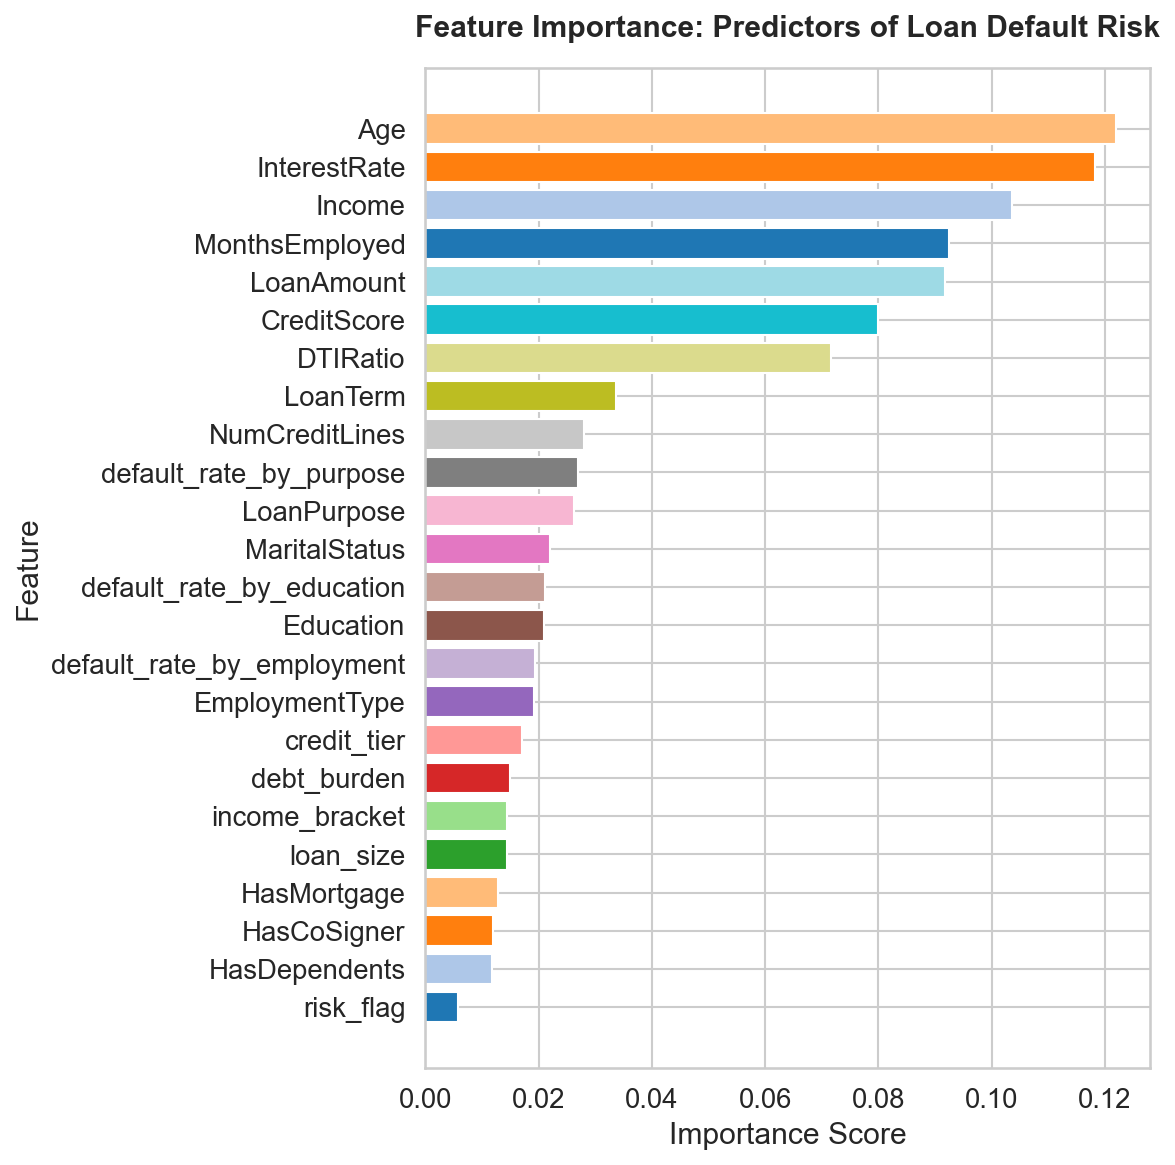

In [31]:
# Set publication quality style
sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams['figure.dpi'] = 150

# Feature importance chart
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

# Generate a distinct color for each bar
colors = sns.color_palette('tab20', len(importances))

fig, ax = plt.subplots(figsize=(8, 8))

ax.barh(importances.index, importances.values, color=colors, edgecolor='white')

ax.set_title('Feature Importance: Predictors of Loan Default Risk', fontweight='bold', pad=15)
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
logging.info('Feature importance visualization saved')

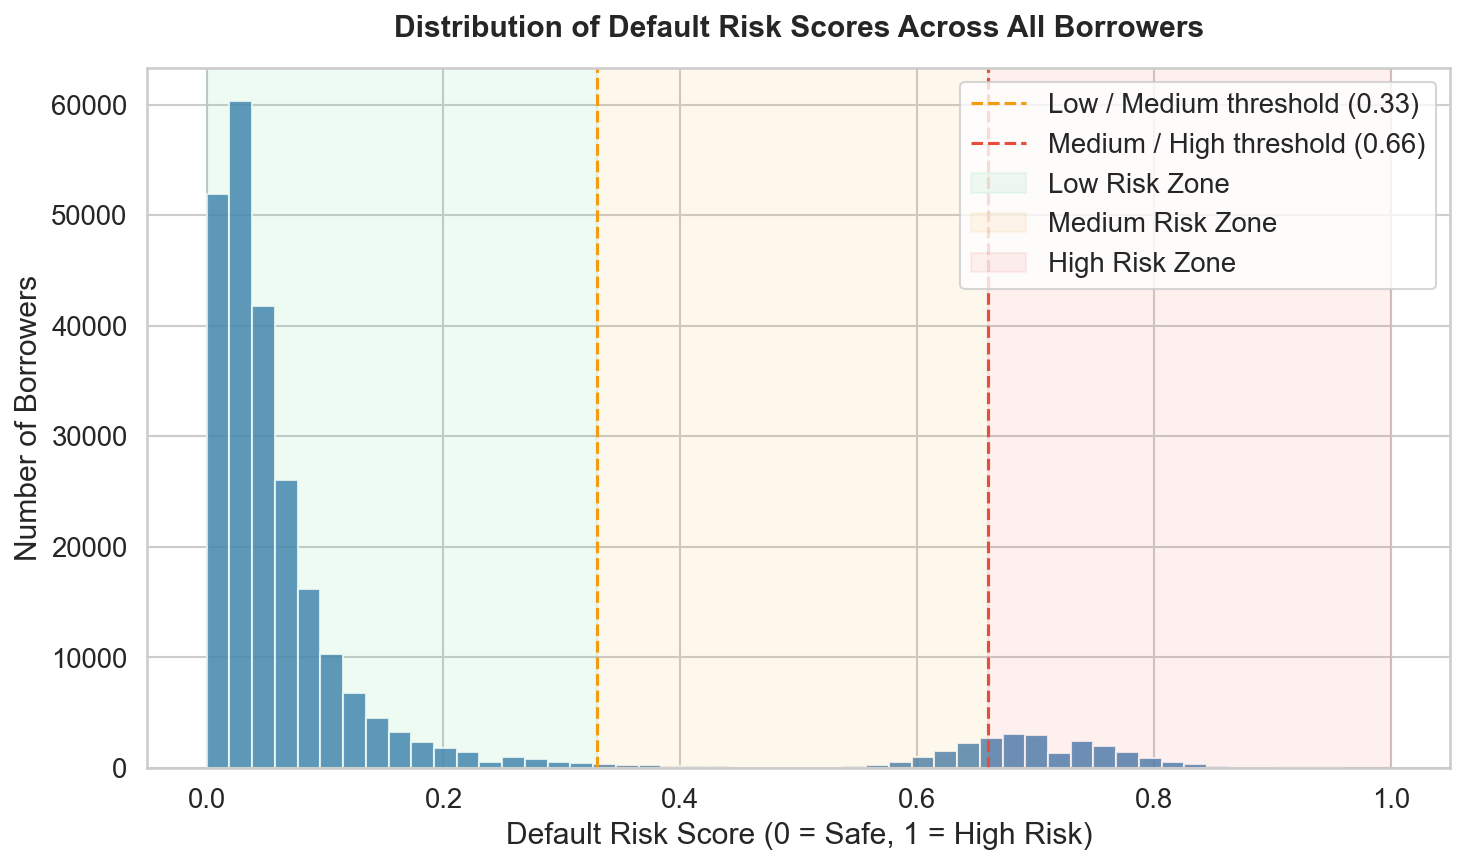

In [32]:
# ── Visualization 2: Distribution of Default Risk Scores ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Assign colors based on risk level
colors = df_model['default_risk_score'].apply(
    lambda x: '#2ecc71' if x < 0.33 else ('#f39c12' if x < 0.66 else '#e74c3c')
)

ax.hist(df_model['default_risk_score'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)

# Add vertical lines showing risk thresholds
ax.axvline(x=0.33, color='#f39c12', linestyle='--', linewidth=1.5, label='Low / Medium threshold (0.33)')
ax.axvline(x=0.66, color='#e74c3c', linestyle='--', linewidth=1.5, label='Medium / High threshold (0.66)')

# Add shaded regions for risk zones
ax.axvspan(0, 0.33, alpha=0.08, color='#2ecc71', label='Low Risk Zone')
ax.axvspan(0.33, 0.66, alpha=0.08, color='#f39c12', label='Medium Risk Zone')
ax.axvspan(0.66, 1.0, alpha=0.08, color='#e74c3c', label='High Risk Zone')

ax.set_title('Distribution of Default Risk Scores Across All Borrowers', fontweight='bold', pad=15)
ax.set_xlabel('Default Risk Score (0 = Safe, 1 = High Risk)')
ax.set_ylabel('Number of Borrowers')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../images/risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
logging.info('Risk score distribution visualization saved')

**Visualization Rationale:**
I chose a feature importance chart because it directly addresses the core research question of which borrower characteristics are the strongest predictors of default risk. By ranking each feature by its contribution to the model, this chart makes the results immediately interpretable for a lender who wants to understand what drives default behavior. It also shows whether the new derived features from D1 (such as credit_tier, debt_burden, and risk_flag) add predictive value beyond the original fields. I also chose a histogram with risk zone shading because it shows the full distribution of model-predicted default scores across all borrowers in an intuitive, operationally meaningful way. The color-coded regions and threshold lines at 0.33 and 0.66 let a lender immediately see what share of applicants fall into each risk tier without needing to interpret raw probabilities. The bimodal pattern also validates that the model is meaningfully separating low- and high-risk borrowers rather than producing undifferentiated scores.

## 14. Summary

This notebook completed the full workflow for the Loan Default Risk project
and directly solves the stated problem of estimating how likely a borrower
is to default. The raw dataset of 255,347 loan applications was loaded from
Kaggle and transformed into a secondary dataset D1 by adding eight new derived
fields including credit tier, income bracket, debt burden, loan size,
group-level default rates, and a composite risk flag. D1 was inserted into
MongoDB Atlas and queried back into a pandas DataFrame for modeling.

A Random Forest classifier was trained on D1 and used to generate a
default risk score between 0 and 1 for every borrower, which was saved back
to MongoDB as a new field on each document. The pipeline solves the problem
because it takes raw borrower financial information — income, credit score,
debt-to-income ratio, employment type, and more — and produces a single
interpretable number that quantifies how risky each borrower is. This means
a lender no longer has to guess or rely on intuition when evaluating a loan
application. Instead, they can query MongoDB for any borrower's
`default_risk_score` and immediately know whether that borrower is low,
medium, or high risk before making a lending decision. The feature importance
chart further supports the solution by revealing which borrower
characteristics drive those scores the most, giving lenders interpretable
insight into what makes a borrower high or low risk.